## BONARES SOC Data: Preparation

---

This notebook **prepares and validates BONARES soil organic carbon (SOC) datasets** from two precision liming experiments in Brandenburg, Germany. The workflow includes:

**Brandenburg Farm 1 (5 fields, 222 SOC measurements):**

1. **Data integration** - Merges five separate CSV files (measurements, sampling points, dates, parameters) into a unified dataframe
2. **Temporal coverage** - Samples collected in 2017-2021
3. **Datacube loading** - Imports Sentinel-1, Sentinel-2, and DEM datacubes for all five fields (2017-2022 time range)
4. **Spatial alignment** - Maps original field_IDs (21, 8, 24, 34, 31) to sequential datacube fields (1-5) using coordinate overlap analysis
5. **Validation** - Verifies spatial containment by checking whether sampling points fall within field boundaries using GeoDataFrame spatial joins
6. **Visualization** - Overlays SOC/TOC sampling points on NDVI maps and creates multi-field comparison plots showing shapefiles, datacube extents, and point locations
7. **Export** - Saves field-specific CSV files with all soil parameters for downstream analysis

**Brandenburg Farm 2 (44 fields, 507 SOC measurements):**

1. **Data integration** - Similar merge workflow for the larger Farm 2 dataset
2. **Temporal analysis** - Identifies sampling years (2017, 2018, 2021 contain carbon measurements; 2019-2020 do not)
3. **Datacube loading** - Trouble downloading the 44 datacubes (somehow SSL error) - so circumvented it and did the spatial alignment using QGIS
4. **Spatial alignment** - Maps original field_IDs to shapefiles using QGIS
5. **Validation** - Verifies spatial containment by checking whether sampling points fall within field boundaries using GeoDataFrame spatial joins
6. **Visualization** - Overlays SOC/TOC sampling points creates multi-field comparison plots showing shapefiles, and point locations

Disclaimer: Somehow BONARES Farm 2 shows 43 different field_IDs but when drawing the shapefiles, I drew 44. I still haven't figured out which field I split in two. But the csv are split on the 44 shapefiles and every fields contains samples. So it can still be used for analysis ;) I hope to still figure out which field though.

7. **Export** - Saves field-specific CSV files with all soil parameters for downstream analysis


The notebook ensures all three spatial data sources (shapefiles, datacubes, sampling points) are properly aligned in EPSG:32633 (UTM Zone 33N) before extracting environmental covariates for SOC modeling.

The corresponding data can be found here: [Google Drive / Field Operations (Exist Pilots) / BONARES](https://drive.google.com/drive/folders/1rmSigoEknQC-xcZnXjJtqe1b236OM6OA?usp=drive_link)

---

In [1]:
# Import libraries
import os  
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from shapely.geometry import box, Point
import geopandas as gpd
from pathlib import Path

import xarray as xr

### BRANDENBURG FARM 1

First dataset: https://doi.org/10.20387/bonares-b4h2-yd8t

Precision liming in Brandenburg (Farm 1)

- 222 SOC measurements
- coordinates and sample time available
- no time-series

In [2]:
# Define path
data_path = "/Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/BONARES/Brandenburg_1/csv_files"

# Import csv files
data_f1 = pd.read_csv(f"{data_path}/extern.ID_E115_PH_BB_DATA_F1.csv")
sampling_points = pd.read_csv(f"{data_path}/extern.ID_E117_PH_BB_SAMPLING_POINTS_F1.csv")
sampling_dates_1 = pd.read_csv(f"{data_path}/extern.ID_E118_PH_BB_SAMPLING_DATES_I_F1.csv")
sampling_dates_2 = pd.read_csv(f"{data_path}/extern.ID_E119_PH_BB_SAMPLING_DATES_II_F1.csv")
parameters = pd.read_csv(f"{data_path}/extern.ID_E120_PH_BB_PARAMETERS.csv")

In [3]:
# Merge csv files
print("Initial data shapes:")
print(f"  data_f1: {data_f1.shape}")
print(f"  sampling_points: {sampling_points.shape}")
print(f"  sampling_dates_1: {sampling_dates_1.shape}")
print(f"  sampling_dates_2: {sampling_dates_2.shape}")
print(f"  parameters: {parameters.shape}")

# 1: Add coordinates
df = data_f1.merge(sampling_points, on='point_ID', how='left')
print(f"\nAfter adding coordinates: {df.shape}")

# 2: Add sampling dates (part 1)
df = df.merge(sampling_dates_1, on='lab_ID', how='left')
print(f"After adding sampling dates I: {df.shape}")

# 3: Add sampling dates (part 2)
df = df.merge(sampling_dates_2, on='date_ID', how='left')
print(f"After adding sampling dates II: {df.shape}")

# 4: Add parameters
df = df.merge(parameters, on='parm_ID', how='left')
print(f"After adding parameters: {df.shape}")
print(f"\nFinal merged dataframe: {df.shape[0]} rows × {df.shape[1]} columns")

Initial data shapes:
  data_f1: (4083, 6)
  sampling_points: (611, 4)
  sampling_dates_1: (640, 2)
  sampling_dates_2: (22, 3)
  parameters: (14, 5)

After adding coordinates: (4083, 9)
After adding sampling dates I: (4083, 10)
After adding sampling dates II: (4083, 12)
After adding parameters: (4083, 16)

Final merged dataframe: 4083 rows × 16 columns


In [4]:
# Transform date columns and verify final dataframe
df['date_sampling'] = pd.to_datetime(df['date_sampling'])
df['date_lab_delivery'] = pd.to_datetime(df['date_lab_delivery'])

print("\nFinal dataframe preview:")
print(df.head())
print(f"\nDimensions: {df.shape}")
print(f"Date range: {df['date_sampling'].min()} to {df['date_sampling'].max()}")


Final dataframe preview:
  pH_BB_ID  farm_ID  point_ID  lab_ID  parm_ID  value         X          Y  \
0  1.1.1.1        1         1       1        1  13.93  426793.1  5886179.9   
1  1.1.1.2        1         1       1        2   5.48  426793.1  5886179.9   
2  1.1.1.3        1         1       1        3  14.81  426793.1  5886179.9   
3  1.1.1.4        1         1       1        4   7.19  426793.1  5886179.9   
4  1.1.1.5        1         1       1        5  34.98  426793.1  5886179.9   

   field_ID  date_ID date_sampling date_lab_delivery    parameter  \
0         1       21    2022-03-24        2022-04-04         Clay   
1         1       21    2022-03-24        2022-04-04    Fine silt   
2         1       21    2022-03-24        2022-04-04  Middle silt   
3         1       21    2022-03-24        2022-04-04  Coarse silt   
4         1       21    2022-03-24        2022-04-04    Fine sand   

  abbreviation unit         method  
0           Cl   M%  DIN ISO 11277  
1          fSi  

In [5]:
# Years of date_sampling
df['date_sampling'].dt.year.unique()

array([2022, 2020, 2021, 2018, 2019, 2017], dtype=int32)

In [6]:
df['parameter'].unique()

array(['Clay', 'Fine silt', 'Middle silt', 'Coarse silt', 'Fine sand',
       'Middle sand', 'Coarse sand', 'soil pH',
       'Phosphorus (plant available)', 'Potassium (plant available)',
       'Magnesia (plant available)', 'Soil organic carbon',
       'Total carbon', 'Totoal nitrogen'], dtype=object)

In [7]:
# Show types of columns
print(df.dtypes)

pH_BB_ID                     object
farm_ID                       int64
point_ID                      int64
lab_ID                        int64
parm_ID                       int64
value                       float64
X                           float64
Y                           float64
field_ID                      int64
date_ID                       int64
date_sampling        datetime64[ns]
date_lab_delivery    datetime64[ns]
parameter                    object
abbreviation                 object
unit                         object
method                       object
dtype: object


In [8]:
# Save final dataframe as csv (same path as data)
output_csv = f"{data_path}/brandenburg1_combined_df.csv"
df.to_csv(output_csv, index=False)
print(f"Saved combined data to: {output_csv}")

Saved combined data to: /Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/BONARES/Brandenburg_1/csv_files/brandenburg1_combined_df.csv


In [9]:
# Filter out parameter, only keep 'Soil organic carbon' and 'Total carbon'
df_carbon = df[(df['parameter'] == 'Soil organic carbon') | (df['parameter'] == 'Total carbon')]

In [10]:
# Look at soc/toc df 
print(df_carbon.head())

       pH_BB_ID  farm_ID  point_ID  lab_ID  parm_ID  value         X  \
303   1.48.48.9        1        48      48        9   0.64  428130.6   
304  1.48.48.10        1        48      48       10   0.64  428130.6   
321   1.51.51.9        1        51      51        9   0.66  428149.6   
322  1.51.51.10        1        51      51       10   0.66  428149.6   
328   1.52.52.9        1        52      52        9   0.71  428152.8   

             Y  field_ID  date_ID date_sampling date_lab_delivery  \
303  5885809.5         8        3    2018-07-26        2018-08-03   
304  5885809.5         8        3    2018-07-26        2018-08-03   
321  5885853.7         8        3    2018-07-26        2018-08-03   
322  5885853.7         8        3    2018-07-26        2018-08-03   
328  5885816.9         8        3    2018-07-26        2018-08-03   

               parameter abbreviation unit         method  
303  Soil organic carbon          SOC   M%  DIN ISO 10694  
304         Total carbon        

In [11]:
# How many sampling points per field_ID?
points_per_field = df_carbon.groupby('field_ID')['point_ID'].nunique()
print(points_per_field)
# Sum of all sampling points
print(f"\nTotal sampling points: {points_per_field.sum()}")

field_ID
8     40
21    40
24    85
31    37
34    20
Name: point_ID, dtype: int64

Total sampling points: 222


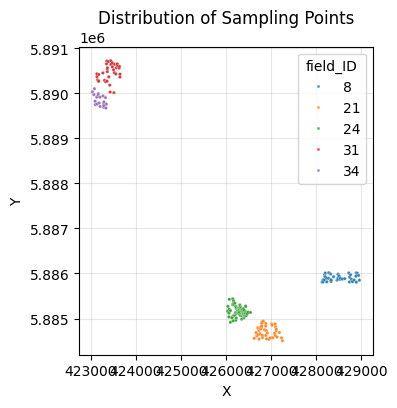

In [12]:
# Visualize the coordinate points to see how they are distributed
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_carbon, x='X', y='Y', hue='field_ID', s=5, alpha=0.7, palette='tab10', legend='full')
plt.title('Distribution of Sampling Points')
plt.gca().set_aspect('equal')
plt.grid(True, alpha=0.3)
plt.show()

### Data Cube Loading and Matching

Analysing the data points in QGIS, we see that it's 5 distinct fields. We created shapefiles for each individual field and downloaded the data cubes.

We will import the datacubes and analyze them with the sample points that we have on SOC and TOC.

In [13]:
# Import all datacubes for Brandenburg fields 1-5
# Store them in a dictionary with field number as key

cube_base_path = "/Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/BONARES/Brandenburg_1"

# Dictionary to store all datacubes
datacubes = {}

# Loop through fields 1-5
for field_num in range(1, 6):
    cube_file = Path(f"{cube_base_path}/scaled_fused_field{field_num}_S1-S2-DEM_2017-2022_cube.nc")
    
    # Check if file exists before trying to open
    if cube_file.exists():
        datacubes[field_num] = xr.open_dataset(cube_file, engine='netcdf4')
        print(f"Loaded field_{field_num}: {datacubes[field_num].dims}")
    else:
        print(f"File not found: {cube_file.name}")

print(f"\nSuccessfully loaded {len(datacubes)} datacubes")
print(f"Available fields: {list(datacubes.keys())}")

Loaded field_1: FrozenMappingWarningOnValuesAccess({'t': 2191, 'y': 53, 'x': 74})
Loaded field_2: FrozenMappingWarningOnValuesAccess({'t': 2191, 'y': 29, 'x': 100})
Loaded field_3: FrozenMappingWarningOnValuesAccess({'t': 2191, 'y': 67, 'x': 67})
Loaded field_4: FrozenMappingWarningOnValuesAccess({'t': 2191, 'y': 68, 'x': 48})
Loaded field_5: FrozenMappingWarningOnValuesAccess({'t': 2191, 'y': 88, 'x': 66})

Successfully loaded 5 datacubes
Available fields: [1, 2, 3, 4, 5]


In [14]:
# Example: Access field 1 datacube
ds = datacubes[1]
ds

<xarray.Dataset> Size: 825MB
Dimensions:           (t: 2191, y: 53, x: 74)
Coordinates:
  * t                 (t) datetime64[ns] 18kB 2017-01-01 ... 2022-12-31
  * x                 (x) float64 592B 4.266e+05 4.266e+05 ... 4.273e+05
  * y                 (y) float64 424B 5.885e+06 5.885e+06 ... 5.884e+06
Data variables: (12/25)
    crs               (t) |S1 2kB ...
    B01               (t, y, x) float32 34MB ...
    B02               (t, y, x) float32 34MB ...
    B03               (t, y, x) float32 34MB ...
    B04               (t, y, x) float32 34MB ...
    B05               (t, y, x) float32 34MB ...
    ...                ...
    viewZenithMean    (t, y, x) float32 34MB ...
    CLD               (t, y, x) float32 34MB ...
    SNW               (t, y, x) float32 34MB ...
    VH                (t, y, x) float32 34MB ...
    VV                (t, y, x) float32 34MB ...
    DEM               (t, y, x) float32 34MB ...
Attributes:
    Conventions:  CF-1.9
    institution:  Copernicus Data Space Ecosystem openEO API - 0.70.0a5.dev20...
    description:  
    title:

#### Helper Functions

In [15]:
# Clearest Day in summer (June-August)
def pick_clearest_summer_day(ds, year=2018, cld_var="CLD", max_cloud=2):
    summer_ds = ds.sel(t=slice(f"{year}-06-01", f"{year}-08-31"))
    cld_mean = summer_ds[cld_var].mean(dim=("y", "x"))
    good = cld_mean.where(cld_mean <= max_cloud, drop=True)
    if good.t.size == 0:
        best_t = cld_mean.idxmin()
    else:
        best_t = good.idxmin()
    snap = summer_ds.sel(t=best_t, method="nearest")
    print(f"Picked {np.datetime_as_string(snap['t'].values)} (mean {cld_var}={float(cld_mean.sel(t=snap['t']).values):.3f})")
    return snap

# Define clearest day picker - flexible
def pick_clearest_day(ds, start, end, cld_var="CLD", max_cloud=2):
    period_ds = ds.sel(t=slice(start, end))
    cld_mean = period_ds[cld_var].mean(dim=("y", "x"))
    good = cld_mean.where(cld_mean <= max_cloud, drop=True)
    if good.t.size == 0:
        best_t = cld_mean.idxmin()
    else:
        best_t = good.idxmin()
    snap = period_ds.sel(t=best_t, method="nearest")
    print(f"Picked {np.datetime_as_string(snap['t'].values)} (mean {cld_var}={float(cld_mean.sel(t=snap['t']).values):.3f})")
    return snap

# Pick day with best data availability (most valid pixels)
def pick_best_data_day(ds, start, end, bands=['B04', 'B08']): # possible to add more bands (sufficient for NDVI)
    """Pick the day with the most valid (non-NaN) pixels across specified bands."""
    period_ds = ds.sel(t=slice(start, end))
    
    valid_counts = []
    for t_idx in range(len(period_ds.t)):
        snap = period_ds.isel(t=t_idx)
        valid = sum(np.sum(~np.isnan(snap[band].values)) for band in bands if band in snap)
        valid_counts.append(valid)
    best_idx = np.argmax(valid_counts)
    snap = period_ds.isel(t=best_idx)    
    total_pixels = sum(snap[band].size for band in bands if band in snap)
    pct_valid = (valid_counts[best_idx] / total_pixels * 100) if total_pixels > 0 else 0
    
    print(f"Picked {np.datetime_as_string(snap['t'].values, unit='D')} ({pct_valid:.1f}% valid pixels)")
    return snap

### Field Mapping

Map field_IDs to datacube fields by checking spatial overlap.

In [16]:
# Create a mapping dictionary
field_mapping = {}  # Will store: {datacube_field_num: field_ID}

print("Matching field_IDs to datacube fields:")

for field_num, ds_temp in datacubes.items():
    # Get this datacube's extent
    cube_x_min = ds_temp.x.min().item()
    cube_x_max = ds_temp.x.max().item()
    cube_y_min = ds_temp.y.min().item()
    cube_y_max = ds_temp.y.max().item()
    
    print(f"\nDatacube Field {field_num}:")
    print(f"  Extent: X=[{cube_x_min:.2f}, {cube_x_max:.2f}], Y=[{cube_y_min:.2f}, {cube_y_max:.2f}]")
    
    # Check each field_ID
    best_match = None
    max_points = 0
    
    for field_id in sorted(df_carbon['field_ID'].unique()):
        field_data = df_carbon[df_carbon['field_ID'] == field_id]
        
        # Count how many points fall within this datacube
        tolerance = 0  # meters
        points_in_cube = field_data[
            (field_data['X'] >= cube_x_min - tolerance) & 
            (field_data['X'] <= cube_x_max + tolerance) &
            (field_data['Y'] >= cube_y_min - tolerance) & 
            (field_data['Y'] <= cube_y_max + tolerance)
        ]
        
        if len(points_in_cube) > 0:
            print(f"    Field ID {field_id}: {len(points_in_cube)}/{len(field_data)} points")
            
            # Track the field_ID with most points in this datacube
            if len(points_in_cube) > max_points:
                max_points = len(points_in_cube)
                best_match = field_id
    
    if best_match:
        field_mapping[field_num] = best_match
        print(f"  Matched to Field ID {best_match} ({max_points} points)")
    else:
        print(f"  No matching field_ID found")

Matching field_IDs to datacube fields:

Datacube Field 1:
  Extent: X=[426575.00, 427305.00], Y=[5884465.00, 5884985.00]
    Field ID 21: 80/80 points
  Matched to Field ID 21 (80 points)

Datacube Field 2:
  Extent: X=[428105.00, 429095.00], Y=[5885775.00, 5886055.00]
    Field ID 8: 80/80 points
  Matched to Field ID 8 (80 points)

Datacube Field 3:
  Extent: X=[425955.00, 426615.00], Y=[5884835.00, 5885495.00]
    Field ID 24: 170/170 points
  Matched to Field ID 24 (170 points)

Datacube Field 4:
  Extent: X=[422975.00, 423445.00], Y=[5889505.00, 5890175.00]
    Field ID 31: 2/74 points
    Field ID 34: 40/40 points
  Matched to Field ID 34 (40 points)

Datacube Field 5:
  Extent: X=[423045.00, 423695.00], Y=[5889925.00, 5890795.00]
    Field ID 31: 74/74 points
    Field ID 34: 10/40 points
  Matched to Field ID 31 (74 points)


In [17]:
print("\nFinal Mapping:")
for field_num, field_id in sorted(field_mapping.items()):
    print(f"  Datacube field_{field_num} -> Field ID {field_id}")


Final Mapping:
  Datacube field_1 -> Field ID 21
  Datacube field_2 -> Field ID 8
  Datacube field_3 -> Field ID 24
  Datacube field_4 -> Field ID 34
  Datacube field_5 -> Field ID 31


In [18]:
# Create field_ID_qgis column based on discovered mapping
# This maps the original field_IDs to sequential numbers (1-5) matching datacube fields

df_carbon = df_carbon.copy()
df_carbon['field_ID_qgis'] = df_carbon['field_ID'].map({21: 1, 8: 2, 24: 3, 34: 4, 31: 5})

print("Field ID Mapping Applied:")
for dc_field, orig_id in field_mapping.items():
    qgis_id = df_carbon[df_carbon['field_ID'] == orig_id]['field_ID_qgis'].iloc[0]
    print(f"  Datacube {dc_field} -> field_ID {orig_id} -> field_ID_qgis {qgis_id}")

Field ID Mapping Applied:
  Datacube 1 -> field_ID 21 -> field_ID_qgis 1
  Datacube 2 -> field_ID 8 -> field_ID_qgis 2
  Datacube 3 -> field_ID 24 -> field_ID_qgis 3
  Datacube 4 -> field_ID 34 -> field_ID_qgis 4
  Datacube 5 -> field_ID 31 -> field_ID_qgis 5


Picked 2017-03-15 (61.7% valid pixels)
Field 5: 74 total samples (SOC + TOC)


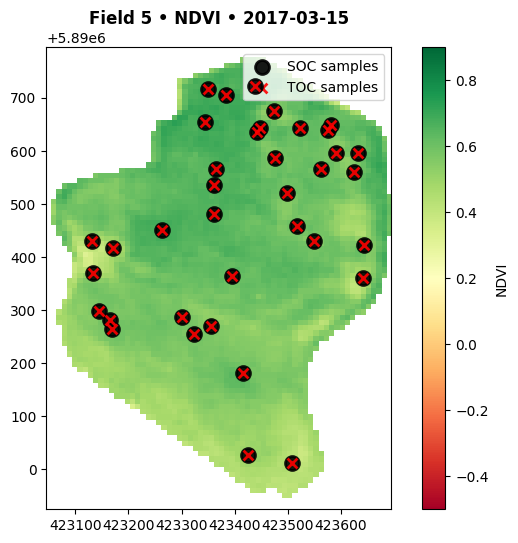

In [19]:
# Visualize NDVI with SOC/TOC sampling points (differentiated)
# Select which field to visualize
field_to_visualize = 5
ds = datacubes[field_to_visualize]

# Pick your favorite helper function
# snap = pick_clearest_summer_day(ds, year=2020)
snap = pick_best_data_day(ds, start="2017-01-01", end="2021-12-31")
ndvi = (snap['B08'] - snap['B04']) / (snap['B08'] + snap['B04'])

# Filter by field_ID_qgis to only show samples from THIS field
extent = [ds.x.min().item(), ds.x.max().item(), ds.y.min().item(), ds.y.max().item()]
field_samples = df_carbon[df_carbon['field_ID_qgis'] == field_to_visualize].copy()

print(f"Field {field_to_visualize}: {len(field_samples)} total samples (SOC + TOC)")

# Split into SOC and TOC
soc_samples = field_samples[field_samples['parameter'] == 'Soil organic carbon']
toc_samples = field_samples[field_samples['parameter'] == 'Total carbon']

# Create plot
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(ndvi, vmin=-0.5, vmax=0.9, cmap="RdYlGn", extent=extent, origin='upper')

# Overlay SOC points
if not soc_samples.empty:
    ax.scatter(soc_samples['X'], soc_samples['Y'], c='black', s=100, marker='o',
              linewidths=2, alpha=0.9, label='SOC samples', zorder=10)

# Overlay TOC points
if not toc_samples.empty:
    ax.scatter(toc_samples['X'], toc_samples['Y'], c='red', s=50, marker='x',
              linewidths=2, alpha=0.9, label='TOC samples', zorder=10)

if not field_samples.empty:
    ax.legend(loc='upper right')

ax.set_title(f"Field {field_to_visualize} • NDVI • {np.datetime_as_string(snap['t'].values, unit='D')}", 
            fontweight='bold')
plt.colorbar(im, ax=ax, label='NDVI')
plt.show()

In [20]:
# Save CARBON dataframe with field_ID_qgis column
output_csv = f"{data_path}/brandenburg1_carbon_df.csv"
df_carbon.to_csv(output_csv, index=False)
print(f"\n Saved carbon data to: {output_csv}")


 Saved carbon data to: /Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/BONARES/Brandenburg_1/csv_files/brandenburg1_carbon_df.csv


In [21]:
# Count how many timesteps have valid Sentinel-2 data
print("CHECKING ALL TIMESTEPS FOR VALID B08 DATA\n")

for field_num in sorted(datacubes.keys()):
    ds = datacubes[field_num]
    
    valid_timesteps = []
    for t_idx in range(len(ds.t)):
        sample = ds.isel(t=t_idx)
        pct_valid = (~np.isnan(sample['B08'].values)).sum() / sample['B08'].size * 100
        if pct_valid > 5:  # At least 5% valid pixels
            valid_timesteps.append((t_idx, pd.Timestamp(sample.t.values), pct_valid))
    
    print(f"Field {field_num}: {len(valid_timesteps)} / {len(ds.t)} timesteps have >5% valid B08 data")
    if len(valid_timesteps) > 0 and len(valid_timesteps) <= 10:
        print("  Valid dates:")
        for t_idx, date, pct in valid_timesteps:
            print(f"    {date.date()} (t={t_idx}): {pct:.1f}% valid")
    print()

CHECKING ALL TIMESTEPS FOR VALID B08 DATA

Field 1: 272 / 2191 timesteps have >5% valid B08 data

Field 2: 278 / 2191 timesteps have >5% valid B08 data

Field 3: 265 / 2191 timesteps have >5% valid B08 data

Field 4: 269 / 2191 timesteps have >5% valid B08 data

Field 5: 285 / 2191 timesteps have >5% valid B08 data



### Spatial Overlap Verification

Check the spatial alignment between:
1. **Shapefiles** - Original field boundaries from QGIS
2. **Datacubes** - Raster extents of the NetCDF files
3. **Sampling points** - SOC measurement locations

This ensures all three data sources are correctly aligned and all sampling points fall within their respective field boundaries.

In [22]:
# Load shapefiles for all 5 fields
shapefile_base_path = "/Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/BONARES/Brandenburg_1/shapefiles"

# Dictionary to store shapefiles
shapefiles = {}

print("Loading field shapefiles...\n")
for field_num in range(1, 6):
    shapefile_path = Path(f"{shapefile_base_path}/field_{field_num}.shp")
    
    if shapefile_path.exists():
        shapefiles[field_num] = gpd.read_file(shapefile_path)
        # Ensure CRS matches (should be EPSG:32633)
        if shapefiles[field_num].crs.to_epsg() != 32633:
            print(f"  Field {field_num}: CRS is {shapefiles[field_num].crs}, reprojecting to EPSG:32633")
            shapefiles[field_num] = shapefiles[field_num].to_crs(epsg=32633)
        else:
            print(f"  Field {field_num}: CRS = EPSG:32633")
        
        # Get bounds
        bounds = shapefiles[field_num].total_bounds  # [minx, miny, maxx, maxy]
        print(f"  Bounds: X=[{bounds[0]:.2f}, {bounds[2]:.2f}], Y=[{bounds[1]:.2f}, {bounds[3]:.2f}]")
    else:
        print(f"  Field {field_num}: Shapefile not found at {shapefile_path}")

print(f"\nLoaded {len(shapefiles)} shapefiles")

Loading field shapefiles...

  Field 1: CRS = EPSG:32633
  Bounds: X=[426573.64, 427308.04], Y=[5884464.75, 5884985.60]
  Field 2: CRS = EPSG:32633
  Bounds: X=[428102.39, 429094.80], Y=[5885777.35, 5886059.77]
  Field 3: CRS = EPSG:32633
  Bounds: X=[425952.65, 426619.99], Y=[5884839.95, 5885498.57]
  Field 4: CRS = EPSG:32633
  Bounds: X=[422975.07, 423444.24], Y=[5889501.24, 5890170.13]
  Field 5: CRS = EPSG:32633
  Bounds: X=[423044.87, 423698.15], Y=[5889928.54, 5890791.76]

Loaded 5 shapefiles


In [23]:
# Check spatial containment: Are all sampling points within their field boundaries?

# Convert sampling points to GeoDataFrame
gdf_carbon = gpd.GeoDataFrame(
    df_carbon, 
    geometry=gpd.points_from_xy(df_carbon.X, df_carbon.Y),
    crs="EPSG:32633"
)

containment_summary = []

for field_num in sorted(shapefiles.keys()):
    # Get sampling points for this field
    field_points = gdf_carbon[gdf_carbon['field_ID_qgis'] == field_num].copy()
    
    if len(field_points) == 0:
        print(f"  No sampling points assigned to this field")
        continue
    
    # Get shapefile boundary
    field_boundary = shapefiles[field_num]
    
    # Check which points are within the boundary
    points_within = gpd.sjoin(field_points, field_boundary, how='inner', predicate='within')
    points_outside = field_points[~field_points.index.isin(points_within.index)]
    
    n_total = len(field_points)
    n_within = len(points_within)
    n_outside = len(points_outside)
    pct_within = (n_within / n_total * 100) if n_total > 0 else 0
    
    containment_summary.append({
        'Field': field_num,
        'Total_Points': n_total,
        'Within_Boundary': n_within,
        'Outside_Boundary': n_outside,
        'Percent_Within': pct_within
    })

print("\nSUMMARY:")
summary_df = pd.DataFrame(containment_summary)
print(summary_df.to_string(index=False))

total_points = summary_df['Total_Points'].sum()
total_within = summary_df['Within_Boundary'].sum()


SUMMARY:
 Field  Total_Points  Within_Boundary  Outside_Boundary  Percent_Within
     1            80               80                 0           100.0
     2            80               80                 0           100.0
     3           170              170                 0           100.0
     4            40               40                 0           100.0
     5            74               74                 0           100.0


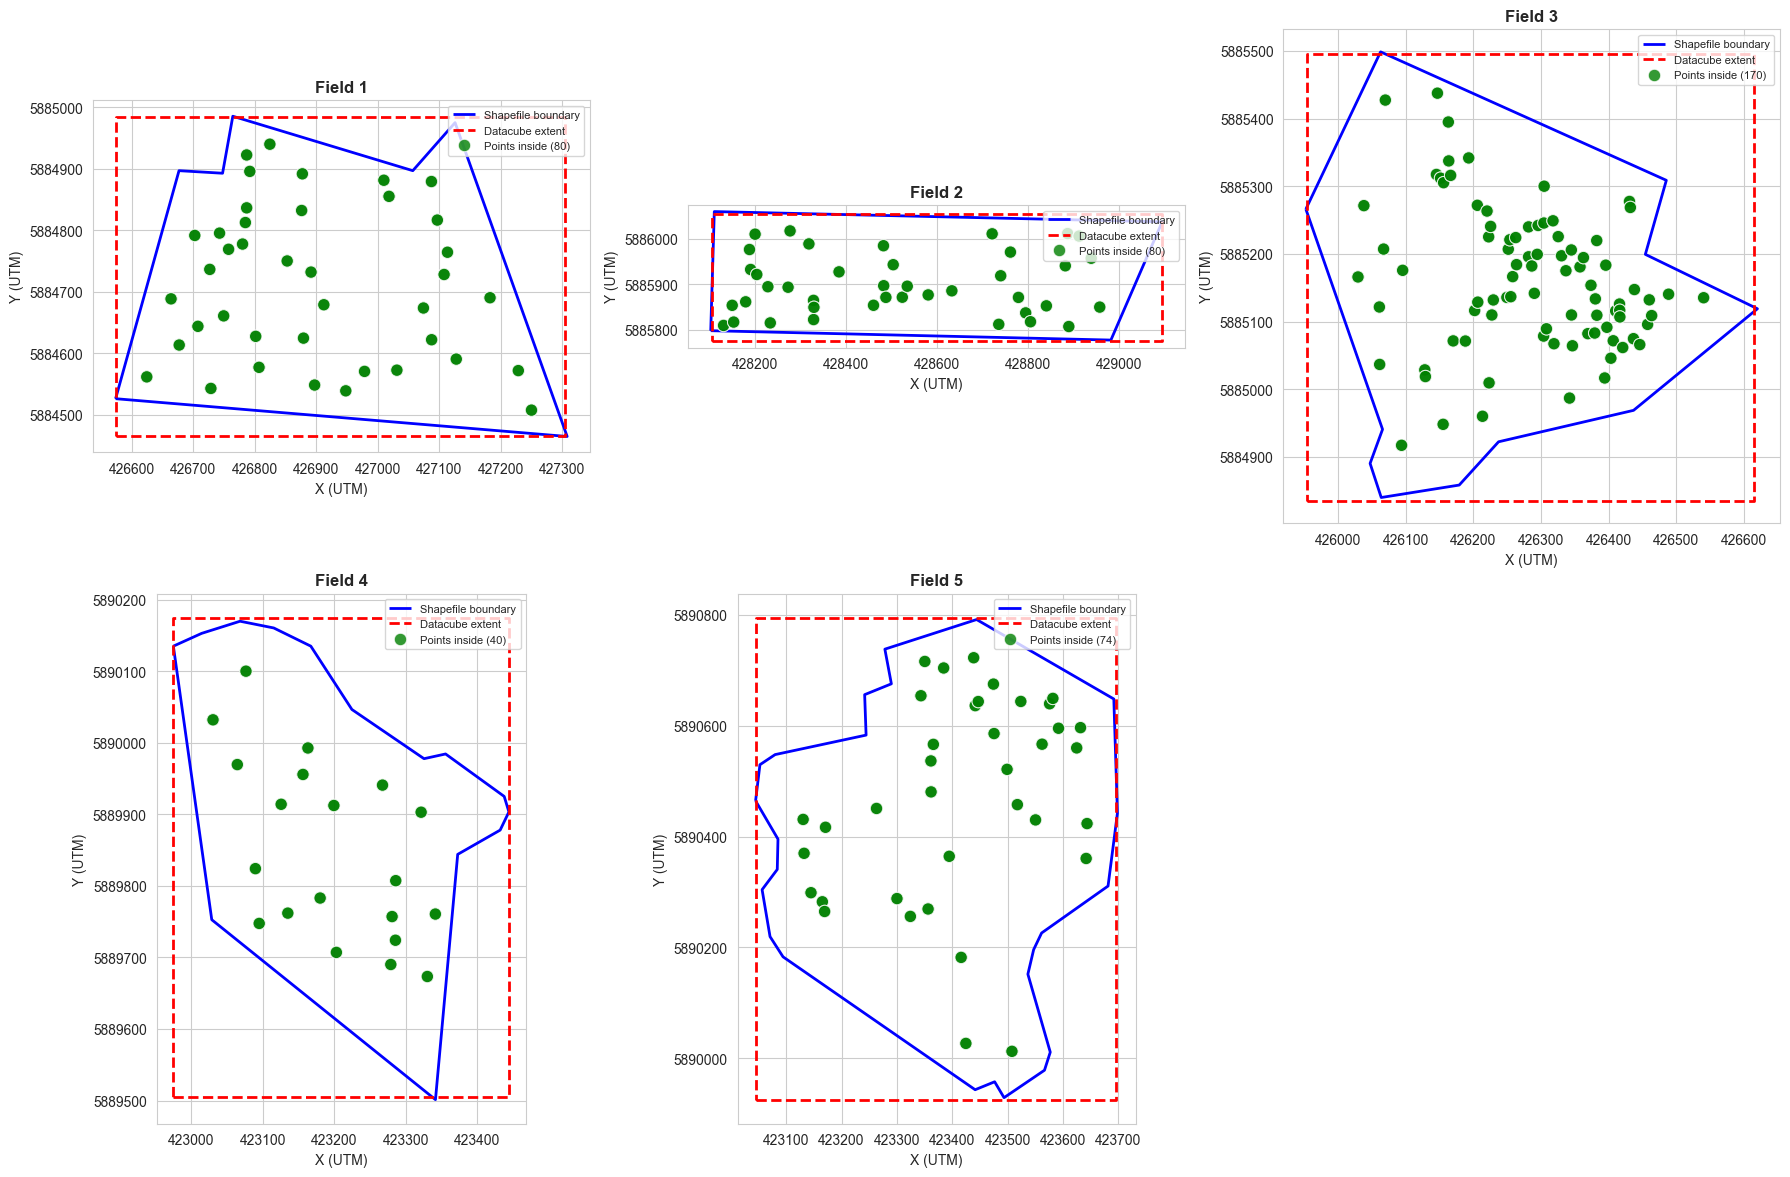

In [24]:
# Visualize spatial overlap: Shapefiles + Datacube extents + Sampling points
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, field_num in enumerate(sorted(shapefiles.keys())):
    ax = axes[idx]
    
    # 1. Plot shapefile boundary
    shapefiles[field_num].boundary.plot(ax=ax, color='blue', linewidth=2, label='Shapefile boundary')
    
    # 2. Plot datacube extent
    if field_num in datacubes:
        ds_field = datacubes[field_num]
        x_min, x_max = ds_field.x.min().item(), ds_field.x.max().item()
        y_min, y_max = ds_field.y.min().item(), ds_field.y.max().item()
        
        ax.plot([x_min, x_max, x_max, x_min, x_min], 
                [y_min, y_min, y_max, y_max, y_min],
                'r--', linewidth=2, label='Datacube extent')
    
    # 3. Prepare point data for seaborn
    field_points = gdf_carbon[gdf_carbon['field_ID_qgis'] == field_num].copy()
    
    if len(field_points) > 0:
        # Spatial join to determine inside/outside
        points_within = gpd.sjoin(field_points, shapefiles[field_num], how='inner', predicate='within')
        
        # Create status column for coloring
        field_points['status'] = 'outside'
        field_points.loc[field_points.index.isin(points_within.index), 'status'] = 'inside'
        
        # Plot with seaborn scatterplot
        sns.scatterplot(data=field_points, x=field_points.geometry.x, y=field_points.geometry.y,
                       hue='status', palette={'inside': 'green', 'outside': 'orange'},
                       style='status', markers={'inside': 'o', 'outside': 'X'},
                       s=80, alpha=0.8, ax=ax, legend=True, zorder=5)
        
        # Customize legend
        handles, labels = ax.get_legend_handles_labels()
        new_labels = []
        for l in labels:
            if l == 'inside':
                new_labels.append(f"Points {l} ({len(field_points[field_points['status']==l])})")
            else:
                new_labels.append(f"{l}")
        ax.legend(handles, new_labels, loc='upper right', fontsize=8, title=None)
    
    ax.set_title(f'Field {field_num}', fontweight='bold', fontsize=12)
    ax.set_xlabel('X (UTM)', fontsize=10)
    ax.set_ylabel('Y (UTM)', fontsize=10)
    ax.set_aspect('equal')
    ax.ticklabel_format(style='plain', axis='both', useOffset=False)

# Remove empty subplot
axes[5].remove()

plt.tight_layout()
plt.show()
sns.reset_defaults()  # Reset to default style

### Save Field-Specific CSV Files

Now that we have the field mapping established, let's save separate CSV files for each field containing ALL parameters (not just SOC/TOC). Each file will include both `field_ID` and `field_ID_qgis` columns for clarity.

In [25]:
# Add field_ID_qgis column to the FULL dataframe (all parameters)
df['field_ID_qgis'] = df['field_ID'].map({21: 1, 8: 2, 24: 3, 34: 4, 31: 5})
df['field_ID_qgis'] = df['field_ID_qgis'].astype('Int64')

In [26]:
# Filter for field_IDs 21, 8, 24
df[df['field_ID'].isin([21, 8, 24])].head()

,pH_BB_ID,farm_ID,point_ID,lab_ID,parm_ID,value,X,Y,field_ID,date_ID,date_sampling,date_lab_delivery,parameter,abbreviation,unit,method,field_ID_qgis
302,1.48.48.8,1,48,48,8,6.20,428130.6,5885809.5,8,3,2018-07-26,2018-08-03,soil pH,pH,NaN,DIN ISO 10390,2
303,1.48.48.9,1,48,48,9,0.64,428130.6,5885809.5,8,3,2018-07-26,2018-08-03,Soil organic carbon,SOC,M%,DIN ISO 10694,2
304,1.48.48.10,1,48,48,10,0.64,428130.6,5885809.5,8,3,2018-07-26,2018-08-03,Total carbon,TC,M%,DIN ISO 10694,2
305,1.48.48.11,1,48,48,11,0.06,428130.6,5885809.5,8,3,2018-07-26,2018-08-03,Totoal nitrogen,TN,M%,DIN ISO 10694,2
306,1.48.48.12,1,48,48,12,6.00,428130.6,5885809.5,8,3,2018-07-26,2018-08-03,Phosphorus (plant available),P,mg/100 g,"Methodenbuch VDLUFA 1991, Band I, A 6.2.1.2.",2


In [27]:
df[df['field_ID_qgis'].isna()]['field_ID'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 22, 23, 25, 26, 27, 28, 29, 30, 32, 33, 35, 36, 37, 38, 39,
       40, 41, 42, 43, 44, 45, 46])

In [28]:
# Split dataframe by field and save separate CSV files
output_path = "/Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/BONARES/Brandenburg_1/csv_files"

# Filter out NaN values and get valid field IDs
valid_field_ids = [fid for fid in df['field_ID_qgis'].unique() if pd.notna(fid)]

for field_qgis_id in sorted(valid_field_ids):
    # Filter data for this field
    df_field = df[df['field_ID_qgis'] == field_qgis_id].copy()
    
    # Skip if empty (shouldn't happen, but safety check)
    if len(df_field) == 0:
        print(f"Field {field_qgis_id}: No data found, skipping")
        continue
    
    # Get original field_ID for this field
    orig_field_id = df_field['field_ID'].iloc[0]
    
    # Create filename
    output_file = f"{output_path}/brandenburg1_field{field_qgis_id}_all_parameters.csv"
    
    # Save to CSV
    df_field.to_csv(output_file, index=False)
    
    # Print summary
    n_samples = df_field['point_ID'].nunique()
    n_measurements = len(df_field)
    n_params = df_field['parameter'].nunique()
    
    print(f"Field {field_qgis_id} (original field_ID {orig_field_id}):")
    print(f"File: {output_file}")
    print(f"{n_samples} sampling points × {n_params} parameters = {n_measurements} measurements")
    print()

print(f"Saved {len(valid_field_ids)} field-specific CSV files")

Field 1 (original field_ID 21):
File: /Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/BONARES/Brandenburg_1/csv_files/brandenburg1_field1_all_parameters.csv
45 sampling points × 14 parameters = 315 measurements

Field 2 (original field_ID 8):
File: /Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/BONARES/Brandenburg_1/csv_files/brandenburg1_field2_all_parameters.csv
80 sampling points × 14 parameters = 484 measurements

Field 3 (original field_ID 24):
File: /Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/BONARES/Brandenburg_1/csv_files/brandenburg1_field3_all_parameters.csv
118 sampling points × 14 parameters = 890 measurements

Field 4 (original field_ID 34):
File: /Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/BONARES/Brandenburg_1/csv_files/brandenburg1_field4_all_parameters.csv
45 sampling points × 14 parameters = 205 measurements

Field 5 (original field_ID 31):
File: /Users/annas/Library/CloudStor

### BRANDENBURG FARM 2

Second dataset: https://maps.bonares.de/mapapps/resources/apps/bonares/index.html?lang=en&mid=5aee1c23-959e-4f45-b9be-8ea6e7ba73e7

Precision liming in Brandenburg (Farm 2)

- 508 SOC measurements
- Sampling date and coordinates recorded
- no time-series

In [29]:
# Define path
data_path_2 = "/Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/BONARES/Brandenburg_2/csv_files"

# Import csv files - using _f2 suffix for all Farm 2 variables
data_f2 = pd.read_csv(f"{data_path_2}/extern.ID_E124_PH_BB_DATA_F2.csv")
sampling_points_f2 = pd.read_csv(f"{data_path_2}/extern.ID_E127_PH_BB_SAMPLING_POINTS_F2.csv")
sampling_dates_1_f2 = pd.read_csv(f"{data_path_2}/extern.ID_E125_PH_BB_SAMPLING_DATES_I_F2.csv")
sampling_dates_2_f2 = pd.read_csv(f"{data_path_2}/extern.ID_E126_PH_BB_SAMPLING_DATES_II_F2.csv")
parameters_f2 = pd.read_csv(f"{data_path_2}/extern.ID_E123_PH_BB_PARAMETERS.csv")

In [30]:
# Merge all CSV files sequentially with validation checks
print("Initial data shapes:")
print(f"  data_f2: {data_f2.shape}")
print(f"  sampling_points_f2: {sampling_points_f2.shape}")
print(f"  sampling_dates_1_f2: {sampling_dates_1_f2.shape}")
print(f"  sampling_dates_2_f2: {sampling_dates_2_f2.shape}")
print(f"  parameters_f2: {parameters_f2.shape}")

# Step 1: Add coordinates
df_f2 = data_f2.merge(sampling_points_f2, on='point_ID', how='left')
print(f"\n After adding coordinates: {df_f2.shape}")

# Step 2: Add sampling dates (part 1)
df_f2 = df_f2.merge(sampling_dates_1_f2, on='lab_ID', how='left')
print(f" After adding sampling dates I: {df_f2.shape}")

# Step 3: Add sampling dates (part 2) - Note: Farm 2 uses 'dates_ID' while Farm 1 uses 'date_ID'
df_f2 = df_f2.merge(sampling_dates_2_f2, left_on='date_ID', right_on='dates_ID', how='left')
print(f" After adding sampling dates II: {df_f2.shape}")

# Step 4: Add parameters
df_f2 = df_f2.merge(parameters_f2, on='parm_ID', how='left')
print(f" After adding parameters: {df_f2.shape}")
print(f"\nFinal merged dataframe: {df_f2.shape[0]} rows × {df_f2.shape[1]} columns")

Initial data shapes:
  data_f2: (6483, 6)
  sampling_points_f2: (1238, 4)
  sampling_dates_1_f2: (1295, 2)
  sampling_dates_2_f2: (31, 3)
  parameters_f2: (14, 5)

 After adding coordinates: (6483, 9)
 After adding sampling dates I: (6483, 10)
 After adding sampling dates II: (6483, 13)
 After adding parameters: (6483, 17)

Final merged dataframe: 6483 rows × 17 columns


In [31]:
# Transform date columns and verify final dataframe
df_f2['date_sampling'] = pd.to_datetime(df_f2['date_sampling'])
df_f2['date_lab_delivery'] = pd.to_datetime(df_f2['date_lab_delivery'])

print("\nFinal dataframe preview:")
print(df_f2.head())
print(f"\nDimensions: {df_f2.shape}")
print(f"Date range: {df_f2['date_sampling'].min()} to {df_f2['date_sampling'].max()}")


Final dataframe preview:
   pH_BB_ID  farm_ID  point_ID  lab_ID  parm_ID  value         X          Y  \
0   2.1.1.9        2         1       1        9   1.48  462573.1  5801470.8   
1  2.1.1.10        2         1       1       10   1.50  462573.1  5801470.8   
2  2.1.1.11        2         1       1       11   0.17  462573.1  5801470.8   
3   2.2.2.1        2         2       2        1  38.23  462602.9  5801523.2   
4   2.2.2.2        2         2       2        2   6.57  462602.9  5801523.2   

   field_ID  date_ID  dates_ID date_sampling date_lab_delivery  \
0         1       24        24    2021-04-13        2021-04-25   
1         1       24        24    2021-04-13        2021-04-25   
2         1       24        24    2021-04-13        2021-04-25   
3         1        5         5    2018-05-30        2018-05-31   
4         1        5         5    2018-05-30        2018-05-31   

             parameter abbreviation unit         method  
0  Soil organic carbon          SOC   M%  DI

In [32]:
# Years of date_sampling
print(df_f2['date_sampling'].dt.year.unique())
print(df_f2['parameter'].unique())
# Show types of columns
print(df_f2.dtypes)

[2021 2018 2020 2017 2019]
['Soil organic carbon' 'Total carbon' 'Totoal nitrogen' 'Clay' 'Fine silt'
 'Middle silt' 'Coarse silt' 'Fine sand' 'Middle sand' 'Coarse sand'
 'soil pH' 'Phosphorus (plant available)' 'Potassium (plant available)'
 'Magnesia (plant available)']
pH_BB_ID                     object
farm_ID                       int64
point_ID                      int64
lab_ID                        int64
parm_ID                       int64
value                       float64
X                           float64
Y                           float64
field_ID                      int64
date_ID                       int64
dates_ID                      int64
date_sampling        datetime64[ns]
date_lab_delivery    datetime64[ns]
parameter                    object
abbreviation                 object
unit                         object
method                       object
dtype: object


In [33]:
# Save final dataframe as csv (same path as data)
output_csv = f"{data_path_2}/brandenburg2_combined_df.csv"
df_f2.to_csv(output_csv, index=False)
print(f" Saved combined data to: {output_csv}")

 Saved combined data to: /Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/BONARES/Brandenburg_2/csv_files/brandenburg2_combined_df.csv


In [34]:
# Filter out parameter, only keep 'Soil organic carbon' and 'Total carbon'
df_carbon_f2 = df_f2[(df_f2['parameter'] == 'Soil organic carbon') | (df_f2['parameter'] == 'Total carbon')].copy()

In [35]:
# How many sampling points per field_ID?
points_per_field = df_carbon_f2.groupby('field_ID')['point_ID'].nunique()
print(points_per_field)

print(f"\nTotal sampling points: {points_per_field.sum()}")

field_ID
1     18
2      4
3      5
4      3
5      3
6     14
7     15
8     15
9      6
10     8
11    76
12     4
13    55
14    15
15    20
16    16
17     4
18     4
19    31
20     5
21    16
22     3
23     8
24    15
25     4
26     7
27    20
28     4
29    12
30     5
31     7
32    12
33     2
34    23
35     4
36     4
37     5
38     4
39     5
40     8
41     8
42     6
43     4
Name: point_ID, dtype: int64

Total sampling points: 507


In [36]:
# Save CARBON dataframe as csv (same path as input data)
output_csv = f"{data_path_2}/brandenburg2_carbon_df.csv"
df_carbon_f2.to_csv(output_csv, index=False)
print(f" Saved carbon data to: {output_csv}")

 Saved carbon data to: /Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/BONARES/Brandenburg_2/csv_files/brandenburg2_carbon_df.csv


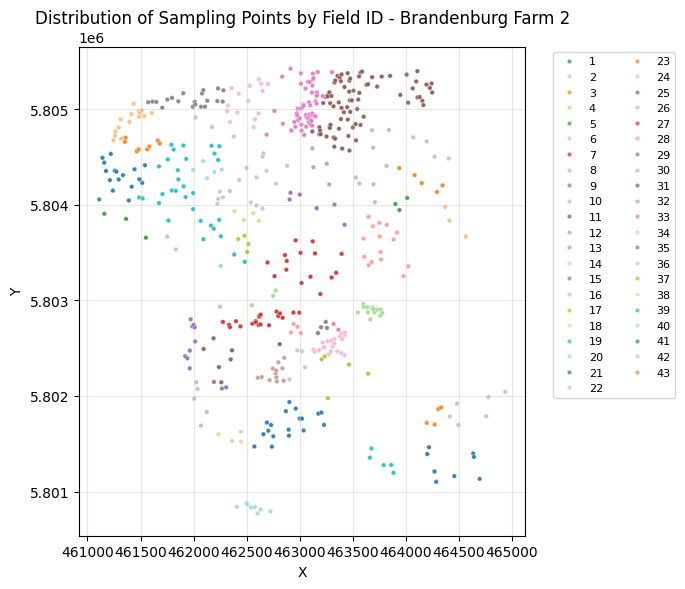

Total fields: 43
Total sampling points: 507


In [37]:
# Visualize the coordinate points colored by field_ID to see field distribution
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df_carbon_f2, x='X', y='Y', hue='field_ID', 
                s=10, alpha=0.7, palette='tab20', legend='brief')
plt.title('Distribution of Sampling Points by Field ID - Brandenburg Farm 2')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

print(f"Total fields: {df_carbon_f2['field_ID'].nunique()}")
print(f"Total sampling points: {df_carbon_f2['point_ID'].nunique()}")

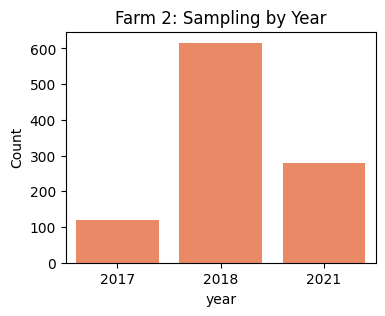

Datacube years needed: 2017-2021


In [38]:
# Quick visual overview of sampling date distribution
df_carbon_f2['year'] = df_carbon_f2['date_sampling'].dt.year
plt.figure(figsize=(4, 3))
sns.countplot(data=df_carbon_f2, x='year', color='coral')
plt.title('Farm 2: Sampling by Year')
plt.ylabel('Count')
plt.show()
print(f"Datacube years needed: {df_carbon_f2['year'].min()}-{df_carbon_f2['year'].max()}")

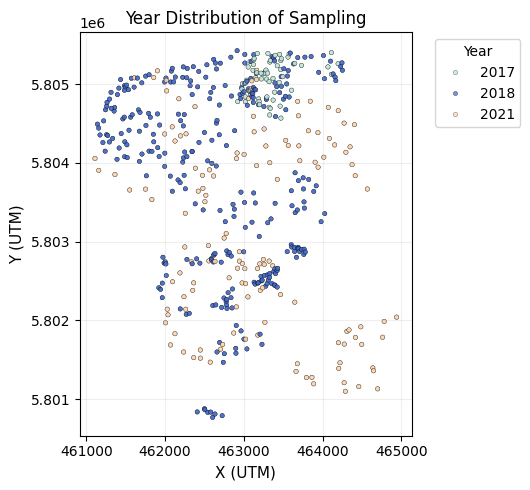

In [39]:
# Geographic-temporal distribution: sampling dates across all fields
df_carbon_f2['year'] = df_carbon_f2['date_sampling'].dt.year

plt.figure(figsize=(6, 5))
sns.scatterplot(data=df_carbon_f2, x='X', y='Y', hue='year', 
                palette='icefire', s=10, alpha=0.7, edgecolor='black')
plt.title('Year Distribution of Sampling')
plt.xlabel('X (UTM)', fontsize=11)
plt.ylabel('Y (UTM)', fontsize=11)
plt.gca().set_aspect('equal')
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### Brandenburg 2: QGIS Field Mapping Validation

Load the QGIS-mapped data and verify the field_ID_qgis assignments are correct by overlaying with shapefiles.

In [46]:
# Load the QGIS-mapped Brandenburg 2 data
df_carbon_qgis_f2 = pd.read_csv(f"{data_path_2}/brandenburg2_afterQGISmapping.csv")

# Convert dates
df_carbon_qgis_f2['date_sampling'] = pd.to_datetime(df_carbon_qgis_f2['date_sampling'], format='%Y/%m/%d')
df_carbon_qgis_f2['date_lab_delivery'] = pd.to_datetime(df_carbon_qgis_f2['date_lab_delivery'], format='%Y/%m/%d')

print(f"Loaded QGIS-mapped data: {len(df_carbon_qgis_f2)} rows")
print(f"\nColumns: {list(df_carbon_qgis_f2.columns)}")
print(f"\nFields mapped in QGIS: {sorted(df_carbon_qgis_f2['field_ID_qgis'].unique())}")
print(f"Number of fields after QGIS mapping: {df_carbon_qgis_f2['field_ID_qgis'].nunique()}")
print(f"Original field_ID count (before QGIS): {df_carbon_f2['field_ID'].nunique()}")
print(f"\n QGIS mapping created {df_carbon_qgis_f2['field_ID_qgis'].nunique()} fields from original {df_carbon_f2['field_ID'].nunique()} fields")

Loaded QGIS-mapped data: 1016 rows

Columns: ['pH_BB_ID', 'farm_ID', 'point_ID', 'lab_ID', 'parm_ID', 'value', 'X', 'Y', 'field_ID', 'date_ID', 'dates_ID', 'date_sampling', 'date_lab_delivery', 'parameter', 'abbreviation', 'unit', 'method', 'field_ID_qgis']

Fields mapped in QGIS: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44)]
Number of fields after QGIS mapping: 44
Original field_ID count (before QGIS): 43

 QGIS mapping created 44 fi

In [47]:
# Load shapefiles for all 44 Brandenburg 2 fields
shapefile_base_path_f2 = "/Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/BONARES/Brandenburg_2/shapefiles"

shapefiles_f2 = {}

print("Loading Brandenburg 2 field shapefiles...\n")
for field_num in range(1, 45):
    shapefile_path = Path(f"{shapefile_base_path_f2}/field{field_num}.shp")
    
    if shapefile_path.exists():
        shapefiles_f2[field_num] = gpd.read_file(shapefile_path)
        
        # Ensure CRS matches (should be EPSG:32633)
        if shapefiles_f2[field_num].crs.to_epsg() != 32633:
            print(f"  Field {field_num}: CRS is {shapefiles_f2[field_num].crs}, reprojecting to EPSG:32633")
            shapefiles_f2[field_num] = shapefiles_f2[field_num].to_crs(epsg=32633)
        
        # Get bounds
        bounds = shapefiles_f2[field_num].total_bounds
        if field_num <= 5 or field_num % 10 == 0:  # Print sample fields
            print(f" Field {field_num}: X=[{bounds[0]:.2f}, {bounds[2]:.2f}], Y=[{bounds[1]:.2f}, {bounds[3]:.2f}]")
    else:
        print(f" Field {field_num}: Shapefile not found")

print(f"\nLoaded {len(shapefiles_f2)} shapefiles out of 44 expected")

Loading Brandenburg 2 field shapefiles...

 Field 1: X=[462369.00, 462841.78], Y=[5800724.52, 5800914.97]
 Field 2: X=[463470.04, 464044.37], Y=[5801107.29, 5801561.51]
 Field 3: X=[463956.50, 464774.37], Y=[5800934.15, 5801533.81]
 Field 4: X=[461924.89, 462238.58], Y=[5801617.92, 5802210.60]
 Field 5: X=[463945.29, 464523.90], Y=[5804452.80, 5804785.15]
 Field 10: X=[461165.40, 461747.96], Y=[5804419.98, 5805090.64]
 Field 20: X=[462553.18, 462914.71], Y=[5802095.09, 5802488.80]
 Field 30: X=[462159.51, 462947.70], Y=[5803880.40, 5804670.92]
 Field 40: X=[463995.23, 464687.97], Y=[5803532.41, 5804078.44]

Loaded 44 shapefiles out of 44 expected


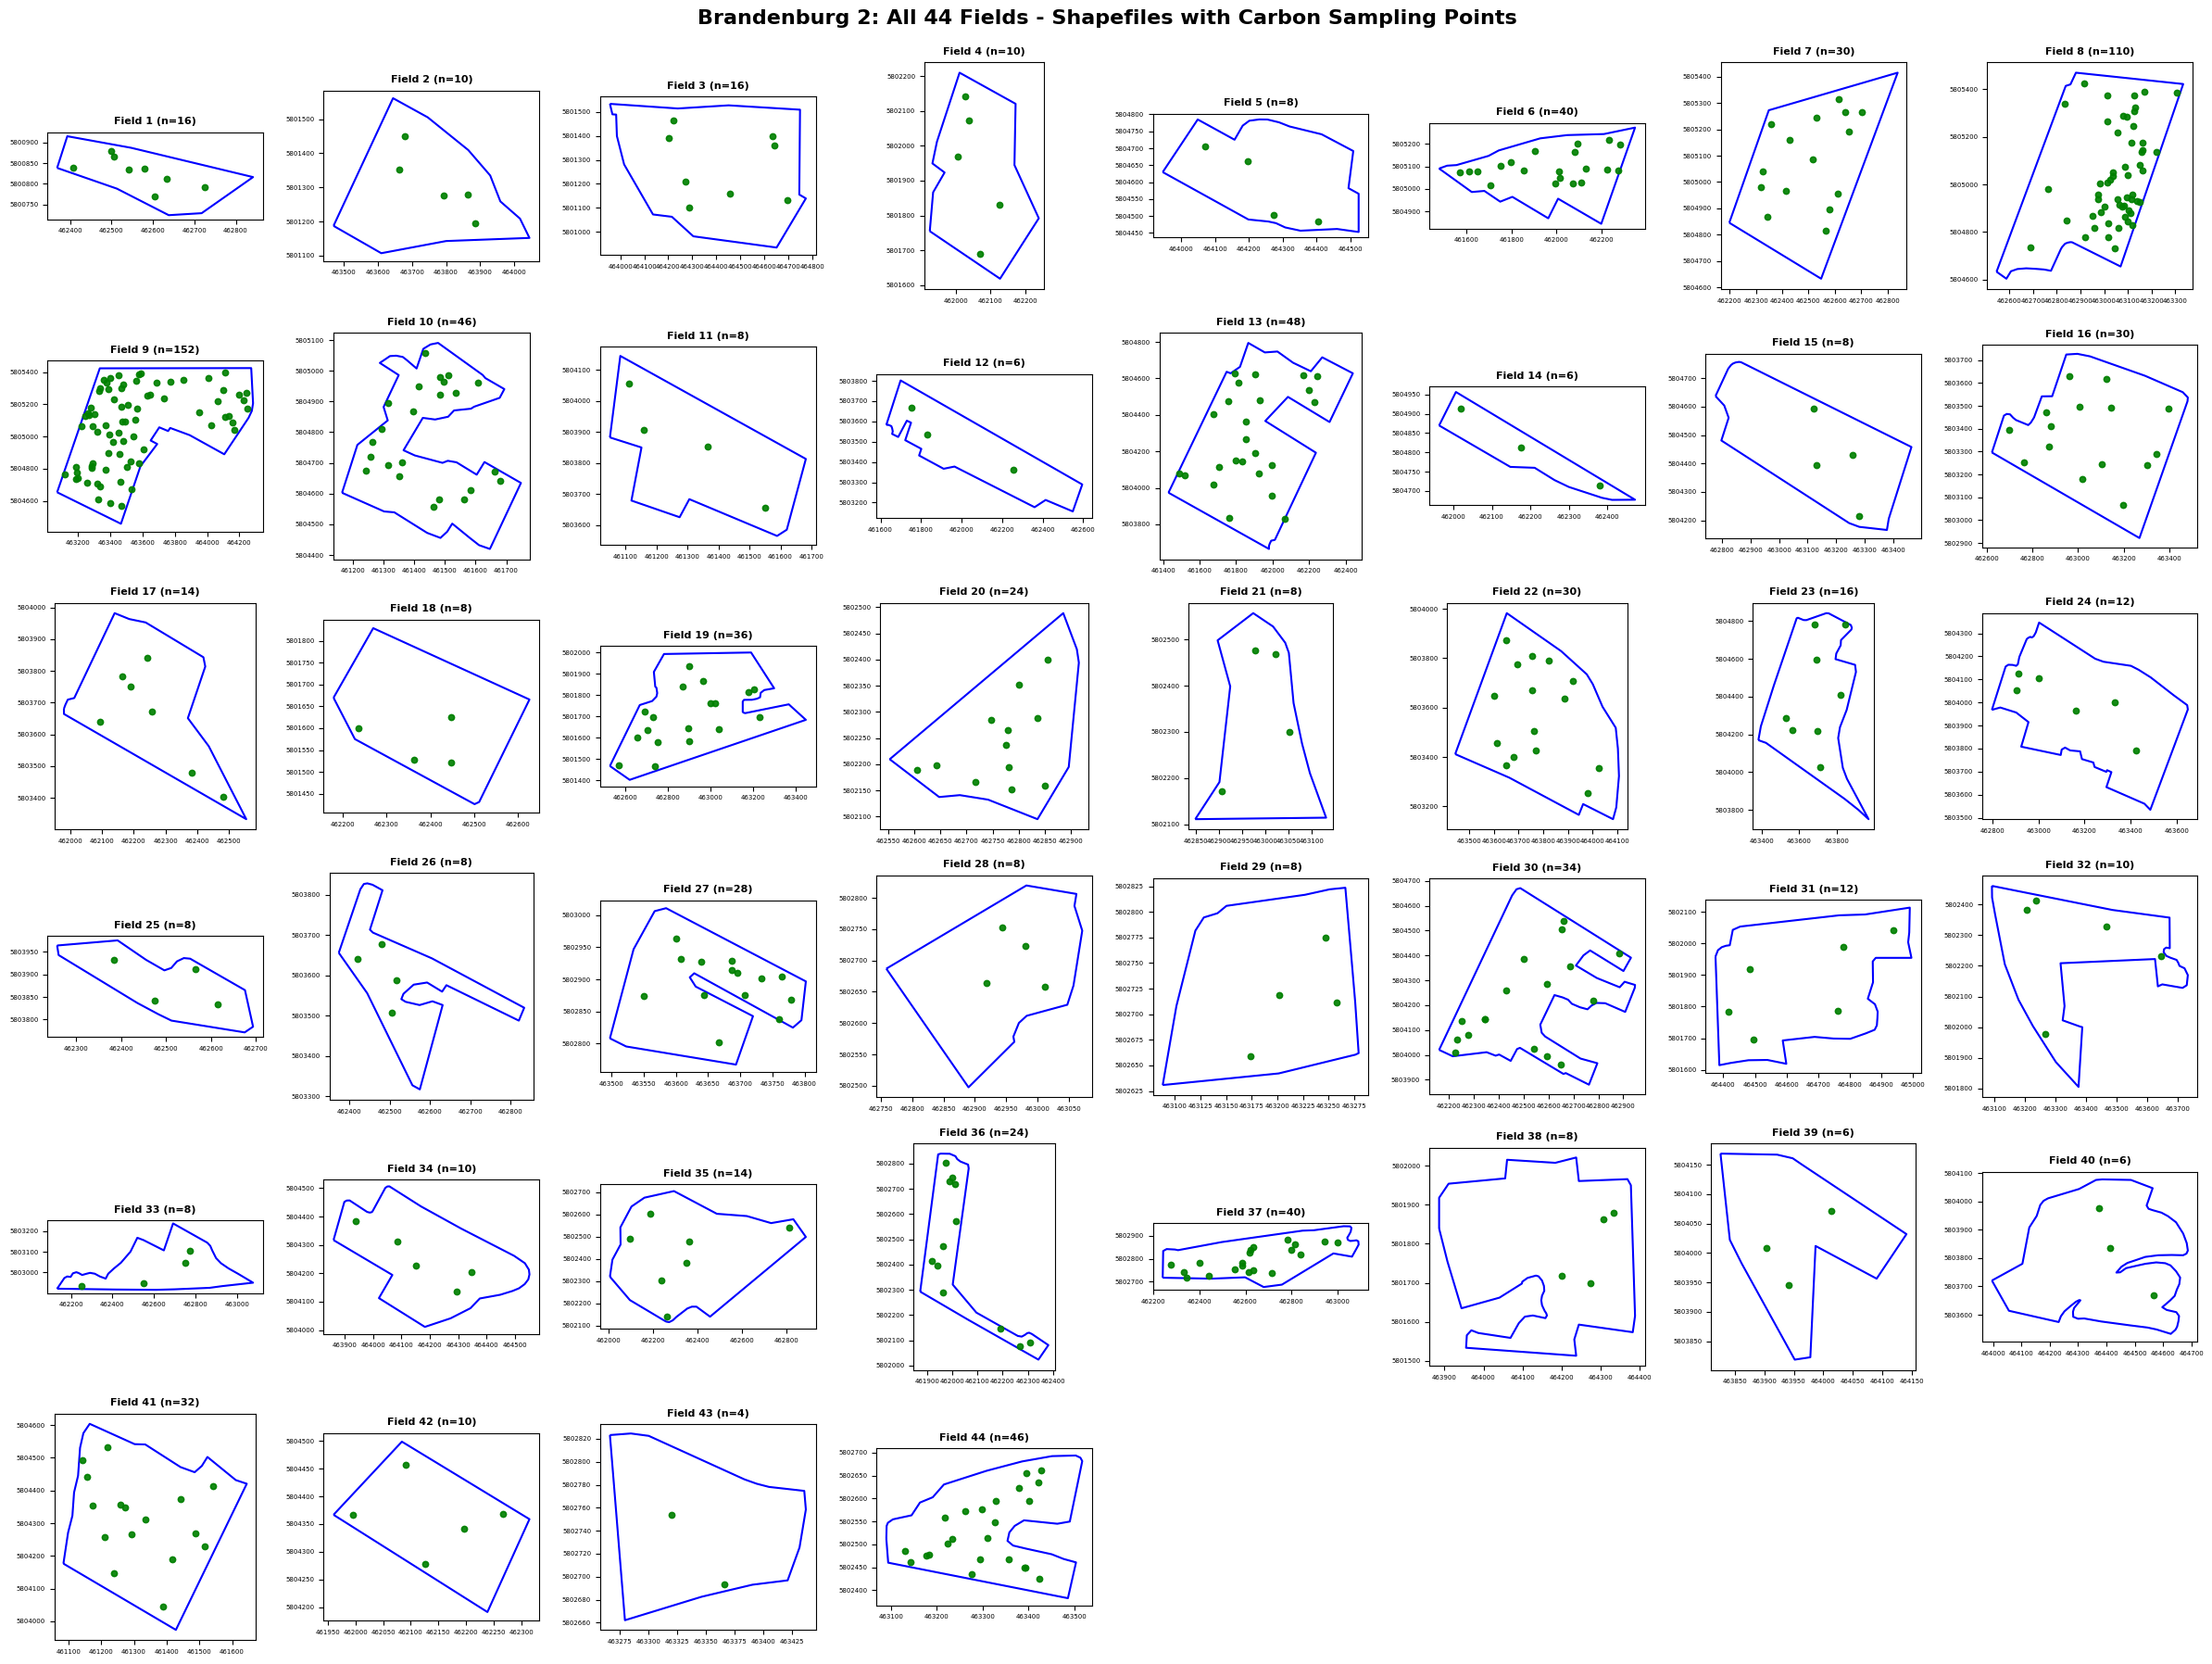


Total shapefiles: 44
Fields with carbon data: 44
Fields without carbon data: 0


In [48]:
# Visualize all 44 Brandenburg 2 fields with shapefiles and carbon data
fig, axes = plt.subplots(6, 8, figsize=(24, 18))
axes = axes.flatten()

# Get fields with carbon data
fields_with_data = set(df_carbon_qgis_f2['field_ID_qgis'].unique())

for field_num in range(1, 45):
    ax = axes[field_num - 1]
    
    # Check if this field has a shapefile
    if field_num not in shapefiles_f2:
        ax.text(0.5, 0.5, f'Field {field_num}\nNo shapefile', 
                ha='center', va='center', fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    
    # Plot shapefile boundary
    shapefiles_f2[field_num].boundary.plot(ax=ax, color='blue', linewidth=1.5)
    
    # Check if this field has carbon data
    if field_num in fields_with_data:
        # Get sampling points for this field
        field_points = df_carbon_qgis_f2[df_carbon_qgis_f2['field_ID_qgis'] == field_num]
        
        if len(field_points) > 0:
            ax.scatter(field_points['X'], field_points['Y'], 
                      c='green', s=20, alpha=0.7, zorder=5)
            title_color = 'black'
            n_points = len(field_points)
            ax.set_title(f'Field {field_num} (n={n_points})', 
                        fontweight='bold', fontsize=8, color=title_color)
    else:
        # No carbon data for this field
        ax.set_title(f'Field {field_num} (no data)', 
                    fontweight='bold', fontsize=8, color='red')
    
    ax.set_xlabel('', fontsize=6)
    ax.set_ylabel('', fontsize=6)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=5)
    ax.ticklabel_format(style='plain', axis='both', useOffset=False)

# Remove extra subplots (we have 48 subplots but only need 44)
for i in range(44, 48):
    axes[i].remove()

plt.suptitle('Brandenburg 2: All 44 Fields - Shapefiles with Carbon Sampling Points', 
             fontweight='bold', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

# Print summary
print(f"\nTotal shapefiles: {len(shapefiles_f2)}")
print(f"Fields with carbon data: {len(fields_with_data)}")
print(f"Fields without carbon data: {44 - len(fields_with_data)}")

In [43]:
# Convert Brandenburg 2 sampling points to GeoDataFrame
gdf_carbon_f2 = gpd.GeoDataFrame(
    df_carbon_qgis_f2,
    geometry=gpd.points_from_xy(df_carbon_qgis_f2.X, df_carbon_qgis_f2.Y),
    crs="EPSG:32633"
)

# Check spatial containment for each field
containment_summary_f2 = []

print("Checking spatial containment for Brandenburg 2...\n")

for field_num in sorted(shapefiles_f2.keys()):
    # Get sampling points assigned to this field
    field_points = gdf_carbon_f2[gdf_carbon_f2['field_ID_qgis'] == field_num].copy()
    
    if len(field_points) == 0:
        print(f"Field {field_num}: No points assigned")
        continue
    
    # Get shapefile boundary
    field_boundary = shapefiles_f2[field_num]
    
    # Check which points are within the boundary
    points_within = gpd.sjoin(field_points, field_boundary, how='inner', predicate='within')
    points_outside = field_points[~field_points.index.isin(points_within.index)]
    
    n_total = len(field_points)
    n_within = len(points_within)
    n_outside = len(points_outside)
    pct_within = (n_within / n_total * 100) if n_total > 0 else 0
    
    containment_summary_f2.append({
        'Field': field_num,
        'Total_Points': n_total,
        'Within_Boundary': n_within,
        'Outside_Boundary': n_outside,
        'Percent_Within': pct_within
    })
    
    # Print fields with issues
    if n_outside > 0:
        print(f"Field {field_num}: {n_within}/{n_total} points within boundary ({pct_within:.1f}%) - ⚠ {n_outside} outside")

print("SUMMARY: Are the points within the respective field boundaries:")
summary_df_f2 = pd.DataFrame(containment_summary_f2)
print(summary_df_f2.to_string(index=False))

total_points_f2 = summary_df_f2['Total_Points'].sum()
total_within_f2 = summary_df_f2['Within_Boundary'].sum()
print(f"\n Overall: {total_within_f2}/{total_points_f2} points within boundaries ({total_within_f2/total_points_f2*100:.1f}%)")

Checking spatial containment for Brandenburg 2...

SUMMARY: Are the points within the respective field boundaries:
 Field  Total_Points  Within_Boundary  Outside_Boundary  Percent_Within
     1            16               16                 0           100.0
     2            10               10                 0           100.0
     3            16               16                 0           100.0
     4            10               10                 0           100.0
     5             8                8                 0           100.0
     6            40               40                 0           100.0
     7            30               30                 0           100.0
     8           110              110                 0           100.0
     9           152              152                 0           100.0
    10            46               46                 0           100.0
    11             8                8                 0           100.0
    12             6 

### Save Field-Specific CSV Files

Create separate CSV files for each field (similar to Brandenburg 1), containing all soil parameters.

In [44]:
# Load the FULL Brandenburg 2 dataset (all parameters, not just carbon)
df_f2_full = pd.read_csv(f"{data_path_2}/brandenburg2_combined_df.csv")

# Convert date columns
df_f2_full['date_sampling'] = pd.to_datetime(df_f2_full['date_sampling'])
df_f2_full['date_lab_delivery'] = pd.to_datetime(df_f2_full['date_lab_delivery'])

print(f"Loaded full Brandenburg 2 dataset: {df_f2_full.shape}")
print(f"Parameters: {df_f2_full['parameter'].unique()}")

# Add field_ID_qgis column by merging with the QGIS-mapped data
# Use point_ID as the key to transfer field_ID_qgis assignments
qgis_mapping = df_carbon_qgis_f2[['point_ID', 'field_ID_qgis']].drop_duplicates()
df_f2_full = df_f2_full.merge(qgis_mapping, on='point_ID', how='left')

# Convert field_ID_qgis to integer type
df_f2_full['field_ID_qgis'] = df_f2_full['field_ID_qgis'].astype('Int64')

print(f"\nAfter adding field_ID_qgis: {df_f2_full.shape}")
print(f"Fields mapped: {sorted(df_f2_full['field_ID_qgis'].dropna().unique())}")

# Split Brandenburg 2 dataframe by field and save separate CSV files
output_path_f2 = "/Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/BONARES/Brandenburg_2/csv_files"

print("\nCreating field-specific CSV files for Brandenburg 2...\n")

# Get list of fields with data
valid_field_ids_f2 = sorted([int(fid) for fid in df_f2_full['field_ID_qgis'].unique() 
                              if pd.notna(fid)])

for field_qgis_id in valid_field_ids_f2:
    # Filter data for this field
    df_field = df_f2_full[df_f2_full['field_ID_qgis'] == field_qgis_id].copy()
    
    if len(df_field) == 0:
        print(f"Field {field_qgis_id}: No data found, skipping")
        continue
    
    # Create filename
    output_file = f"{output_path_f2}/brandenburg2_field{field_qgis_id}_all_parameters.csv"
    
    # Save to CSV
    df_field.to_csv(output_file, index=False)

print(f"\n Saved {len(valid_field_ids_f2)} field-specific CSV files to:")
print(f"  {output_path_f2}/brandenburg2_field{{1-44}}_all_parameters.csv")

Loaded full Brandenburg 2 dataset: (6483, 17)
Parameters: ['Soil organic carbon' 'Total carbon' 'Totoal nitrogen' 'Clay' 'Fine silt'
 'Middle silt' 'Coarse silt' 'Fine sand' 'Middle sand' 'Coarse sand'
 'soil pH' 'Phosphorus (plant available)' 'Potassium (plant available)'
 'Magnesia (plant available)']

After adding field_ID_qgis: (6483, 18)
Fields mapped: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44)]

Creating field-specific CSV fil

Continued analysis of BONARES data can be found in -> [BONARES_2_analysis.ipynb](/Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/notebooks/BONARES_2_analysis.ipynb)